# Clinical NER Pipeline: BioBERT and BioBERT + GENIA



## Step 0: Environment Setup



In [ ]:
# Kaggle / notebook environment setup
!pip install -q \
  "transformers==4.46.3" \
  "accelerate==0.34.2" \
  "peft==0.13.2" \
  "datasets" \
  "evaluate==0.4.3" \
  "seqeval==1.2.2" \
  "scikit-learn"

print("If this is the first run in a fresh session, restart the Kaggle session after installation.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.7/320.7 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 89.9 MB/s eta 0:00:00
If this is the first run in a fresh session, restart the Kaggle session after installation.


In [ ]:
import os
import json
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import Dataset, DatasetDict
from evaluate import load
from sklearn.metrics import confusion_matrix

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    TrainingArguments,
    Trainer,
)


random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# project paths
PROJECT_DIR = "/kaggle/input/datasets/shinjinisupakar/clinicalnlp"
BC5CDR_DIR = os.path.join(PROJECT_DIR, "Processed_Data", "Processed_Data", "ner", "bc5cdr")
GENIA_DIR = os.path.join(PROJECT_DIR, "Processed_Data", "Processed_Data", "triggers", "genia")
OUTPUT_DIR = "/kaggle/working"

BIOBERT_OUTPUT_DIR = os.path.join(OUTPUT_DIR, "results_biobert")
BIOBERT_GENIA_OUTPUT_DIR = os.path.join(OUTPUT_DIR, "results_biobert_genia")

print("BC5CDR_DIR exists:", os.path.exists(BC5CDR_DIR))
print("GENIA_DIR exists:", os.path.exists(GENIA_DIR))
print("Using device:", "cuda" if torch.cuda.is_available() else "cpu")


2026-04-11 19:50:30.609694: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775937030.835115      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775937030.900044      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775937031.427477      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775937031.427528      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775937031.427531      23 computation_placer.cc:177] computation placer alr

BC5CDR_DIR exists: True
GENIA_DIR exists: True
Using device: cuda


## Step 1: Data Loading and Inspection



In [ ]:
def load_jsonl(file_path):
    data = []
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            data.append(json.loads(line))
    return data

train_data = load_jsonl(os.path.join(BC5CDR_DIR, "train.jsonl"))
val_data = load_jsonl(os.path.join(BC5CDR_DIR, "validation.jsonl"))
test_data = load_jsonl(os.path.join(BC5CDR_DIR, "test.jsonl"))
genia_train_raw = load_jsonl(os.path.join(GENIA_DIR, "train.jsonl"))

print(f"Loaded BC5CDR train: {len(train_data)}")
print(f"Loaded BC5CDR validation: {len(val_data)}")
print(f"Loaded BC5CDR test: {len(test_data)}")
print(f"Loaded GENIA train: {len(genia_train_raw)}")


Loaded BC5CDR train: 5228
Loaded BC5CDR validation: 5330
Loaded BC5CDR test: 5865
Loaded GENIA train: 7388


In [ ]:
all_labels = [label for doc in train_data for label in doc["labels"]]
label_counts = Counter(all_labels)

print("Label distribution in BC5CDR training set:")
for label, count in label_counts.items():
    print(f"  {label}: {count}")

seq_lengths = [len(doc["tokens"]) for doc in train_data]
print(f"\nSequence length statistics")
print(f"  Mean: {np.mean(seq_lengths):.2f}")
print(f"  Max : {np.max(seq_lengths)}")
print(f"  Min : {np.min(seq_lengths)}")

print("\nSample BC5CDR training example:")
sample = train_data[0]
for token, label in zip(sample["tokens"][:40], sample["labels"][:40]):
    print(f"{token:20} {label}")


Label distribution in BC5CDR training set:
  B-Chemical: 5203
  O: 96796
  B-Disease: 4182
  I-Disease: 2570
  I-Chemical: 571

Sequence length statistics
  Mean: 20.91
  Max : 133
  Min : 1

Sample BC5CDR training example:
Naloxone             B-Chemical
reverses             O
the                  O
antihypertensive     O
effect               O
of                   O
clonidine            B-Chemical
.                    O


## Step 2: Label Setup, Tokenizer, and Label Alignment



In [ ]:
label_names = ["O", "B-Chemical", "I-Chemical", "B-Disease", "I-Disease"]
label2id = {label: i for i, label in enumerate(label_names)}
id2label = {i: label for label, i in label2id.items()}

checkpoint_biobert = "dmis-lab/biobert-base-cased-v1.1"
tokenizer_biobert = AutoTokenizer.from_pretrained(checkpoint_biobert)

print("Label mapping:", label2id)
print("Loaded tokenizer for:", checkpoint_biobert)


config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Label mapping: {'O': 0, 'B-Chemical': 1, 'I-Chemical': 2, 'B-Disease': 3, 'I-Disease': 4}
Loaded tokenizer for: dmis-lab/biobert-base-cased-v1.1


In [ ]:
def tokenize_and_align_labels(examples, tokenizer):
    tokenized_inputs = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True,
    )

    aligned_labels = []
    for i, labels in enumerate(examples["labels"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []

        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(label2id[labels[word_idx]])
            else:
                current_label = labels[word_idx]
                if current_label.startswith("B-"):
                    current_label = "I-" + current_label[2:]
                label_ids.append(label2id[current_label])
            previous_word_idx = word_idx

        aligned_labels.append(label_ids)

    tokenized_inputs["labels"] = aligned_labels
    return tokenized_inputs

def align_biobert(examples):
    return tokenize_and_align_labels(examples, tokenizer_biobert)


## Step 3: Dataset Preparation


In [ ]:
def create_hf_dataset(data):
    return Dataset.from_dict({
        "tokens": [x["tokens"] for x in data],
        "labels": [x["labels"] for x in data],
    })

bc5cdr_dataset = DatasetDict({
    "train": create_hf_dataset(train_data),
    "validation": create_hf_dataset(val_data),
    "test": create_hf_dataset(test_data),
})

bc5cdr_dataset


DatasetDict({
    train: Dataset({
        features: ['tokens', 'labels'],
        num_rows: 5228
    })
    validation: Dataset({
        features: ['tokens', 'labels'],
        num_rows: 5330
    })
    test: Dataset({
        features: ['tokens', 'labels'],
        num_rows: 5865
    })
})

In [ ]:
biobert_dataset = bc5cdr_dataset.map(
    align_biobert,
    batched=True,
    remove_columns=["tokens", "labels"]
)

print("BioBERT train shape:", biobert_dataset["train"].shape)


Map:   0%|          | 0/5228 [00:00<?, ? examples/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Map:   0%|          | 0/5330 [00:00<?, ? examples/s]

Map:   0%|          | 0/5865 [00:00<?, ? examples/s]

BioBERT train shape: (5228, 4)


## Step 4: Evaluation Metrics


In [ ]:
seqeval = load("seqeval")

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_predictions = []
    true_labels = []

    for pred, lab in zip(predictions, labels):
        cur_preds = []
        cur_labels = []
        for p_i, l_i in zip(pred, lab):
            if l_i != -100:
                cur_preds.append(label_names[p_i])
                cur_labels.append(label_names[l_i])
        true_predictions.append(cur_preds)
        true_labels.append(cur_labels)

    results = seqeval.compute(predictions=true_predictions, references=true_labels)

    chemical_f1 = results.get("Chemical", {}).get("f1", 0.0)
    disease_f1 = results.get("Disease", {}).get("f1", 0.0)

    return {
        "precision_micro": results["overall_precision"],
        "recall_micro": results["overall_recall"],
        "f1_micro": results["overall_f1"],
        "f1_macro": float(np.mean([chemical_f1, disease_f1])),
        "Chemical_f1": chemical_f1,
        "Disease_f1": disease_f1,
    }


## Step 5: Baseline Model Training



In [ ]:
data_collator_biobert = DataCollatorForTokenClassification(tokenizer_biobert)

In [ ]:
model_biobert = AutoModelForTokenClassification.from_pretrained(
    checkpoint_biobert,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
)

training_args_biobert = TrainingArguments(
    output_dir=BIOBERT_OUTPUT_DIR,
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_steps=100,
    save_strategy="epoch",
    load_best_model_at_end=True,
    seed=42,
    push_to_hub=False,
    report_to="none",
)

trainer_biobert = Trainer(
    model=model_biobert,
    args=training_args_biobert,
    train_dataset=biobert_dataset["train"],
    eval_dataset=biobert_dataset["validation"],
    processing_class=tokenizer_biobert,
    data_collator=data_collator_biobert,
    compute_metrics=compute_metrics,
)

print("Starting BioBERT training...")
trainer_biobert.train()

trainer_biobert.save_model("./saved_biobert_bc5cdr")

print("\nEvaluating BioBERT on test set:")
biobert_test_results = trainer_biobert.evaluate(biobert_dataset["test"])
biobert_test_results


pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Some weights of BertForTokenClassification were not initialized from the model checkpoint at dmis-lab/biobert-base-cased-v1.1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting BioBERT training...


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Precision Micro,Recall Micro,F1 Micro,F1 Macro,Chemical F1,Disease F1
1,0.376700,0.112382,0.799457,0.859139,0.828224,0.821303,0.888545,0.754062
2,0.073500,0.107143,0.825619,0.862892,0.843844,0.836028,0.901293,0.770763
3,0.052800,0.124615,0.818008,0.890418,0.852678,0.846504,0.905149,0.787858
4,0.033300,0.124629,0.845738,0.880304,0.862675,0.856409,0.914101,0.798716
5,0.025500,0.133625,0.843583,0.889584,0.865973,0.860172,0.914527,0.805818


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector


Evaluating BioBERT on test set:


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 0.10624777525663376,
 'eval_precision_micro': 0.816578998636275,
 'eval_recall_micro': 0.8546233051279437,
 'eval_f1_micro': 0.8351681195516812,
 'eval_f1_macro': 0.8295919346077192,
 'eval_Chemical_f1': 0.8856469735411381,
 'eval_Disease_f1': 0.7735368956743003,
 'eval_runtime': 28.99,
 'eval_samples_per_second': 202.311,
 'eval_steps_per_second': 6.347,
 'epoch': 5.0}

## Step 6: GENIA Augmentation



In [ ]:
genia_train = []
for doc in genia_train_raw:
    genia_train.append({
        "tokens": doc["tokens"],
        "labels": ["O"] * len(doc["tokens"])
    })

combined_train_data = train_data + genia_train

combined_dataset = DatasetDict({
    "train": create_hf_dataset(combined_train_data)
})

biobert_combined_train_dataset = combined_dataset.map(
    align_biobert,
    batched=True,
    remove_columns=["tokens", "labels"]
)["train"]

print("Original BC5CDR train size:", len(train_data))
print("GENIA added:", len(genia_train))
print("Combined train size:", len(combined_train_data))


Map:   0%|          | 0/12616 [00:00<?, ? examples/s]

Original BC5CDR train size: 5228
GENIA added: 7388
Combined train size: 12616


In [ ]:
model_biobert_genia = AutoModelForTokenClassification.from_pretrained(
    checkpoint_biobert,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
)

training_args_biobert_genia = TrainingArguments(
    output_dir=BIOBERT_GENIA_OUTPUT_DIR,
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_steps=100,
    save_strategy="epoch",
    load_best_model_at_end=True,
    seed=42,
    push_to_hub=False,
    report_to="none",
)

trainer_biobert_genia = Trainer(
    model=model_biobert_genia,
    args=training_args_biobert_genia,
    train_dataset=biobert_combined_train_dataset,
    eval_dataset=biobert_dataset["validation"],
    processing_class=tokenizer_biobert,
    data_collator=data_collator_biobert,
    compute_metrics=compute_metrics,
)

print("Starting BioBERT + GENIA training...")
trainer_biobert_genia.train()

trainer_biobert_genia.save_model("./saved_biobert_genia_bc5cdr")

print("\nEvaluating BioBERT + GENIA on test set:")
biobert_genia_test_results = trainer_biobert_genia.evaluate(biobert_dataset["test"])
biobert_genia_test_results


Some weights of BertForTokenClassification were not initialized from the model checkpoint at dmis-lab/biobert-base-cased-v1.1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting BioBERT + GENIA training...


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Precision Micro,Recall Micro,F1 Micro,F1 Macro,Chemical F1,Disease F1
1,0.041700,0.110837,0.810497,0.830779,0.820513,0.815793,0.873738,0.757848
2,0.019300,0.118399,0.820033,0.881764,0.849779,0.843626,0.904858,0.782395
3,0.011300,0.127292,0.833169,0.883120,0.857418,0.851968,0.906098,0.797839
4,0.006800,0.139107,0.840258,0.883537,0.861354,0.855471,0.911987,0.798956
5,0.003800,0.147997,0.845306,0.879679,0.862150,0.856555,0.910556,0.802554


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector


Evaluating BioBERT + GENIA on test set:


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 0.11418061703443527,
 'eval_precision_micro': 0.7929714341808187,
 'eval_recall_micro': 0.8235294117647058,
 'eval_f1_micro': 0.8079615923184638,
 'eval_f1_macro': 0.8049213073971561,
 'eval_Chemical_f1': 0.8564412542500944,
 'eval_Disease_f1': 0.7534013605442177,
 'eval_runtime': 29.3772,
 'eval_samples_per_second': 199.645,
 'eval_steps_per_second': 6.263,
 'epoch': 5.0}

## Step 7: Results Comparison



In [ ]:
results_data = [
    {
        "Model": "BioBERT",
        "Precision": biobert_test_results["eval_precision_micro"],
        "Recall": biobert_test_results["eval_recall_micro"],
        "F1 (micro)": biobert_test_results["eval_f1_micro"],
        "F1 (macro)": biobert_test_results["eval_f1_macro"],
        "Chemical F1": biobert_test_results["eval_Chemical_f1"],
        "Disease F1": biobert_test_results["eval_Disease_f1"],
    },
    {
        "Model": "BioBERT + GENIA",
        "Precision": biobert_genia_test_results["eval_precision_micro"],
        "Recall": biobert_genia_test_results["eval_recall_micro"],
        "F1 (micro)": biobert_genia_test_results["eval_f1_micro"],
        "F1 (macro)": biobert_genia_test_results["eval_f1_macro"],
        "Chemical F1": biobert_genia_test_results["eval_Chemical_f1"],
        "Disease F1": biobert_genia_test_results["eval_Disease_f1"],
    },
]

results_df = pd.DataFrame(results_data).round(4)
display(results_df)

results_df.to_csv("biobert_vs_biobert_genia_results.csv", index=False)
print("Saved: biobert_vs_biobert_genia_results.csv")


,Model,Precision,Recall,F1 (micro),F1 (macro),Chemical F1,Disease F1
0,BioBERT,0.8166,0.8546,0.8352,0.8296,0.8856,0.7735
1,BioBERT + GENIA,0.7930,0.8235,0.8080,0.8049,0.8564,0.7534


Saved: biobert_vs_biobert_genia_results.csv


## Step 8: Visualization and Model Comparison



In [ ]:
def get_predictions(trainer, dataset):
    predictions, labels, _ = trainer.predict(dataset)
    predictions = np.argmax(predictions, axis=2)
    return predictions, labels

def reconstruct_tags(subword_preds, aligned_true_labels, label_names):
    reconstructed = []
    for p_idx, true_l in zip(subword_preds, aligned_true_labels):
        if true_l != -100:
            reconstructed.append(label_names[p_idx])
    return reconstructed

def flatten_word_level_predictions(preds, dataset_split, label_names):
    y_true, y_pred = [], []
    for i in range(len(dataset_split)):
        true_ids = dataset_split[i]["labels"]
        pred_tags = reconstruct_tags(preds[i], true_ids, label_names)
        true_tags = [label_names[idx] for idx in true_ids if idx != -100]

        if len(pred_tags) == len(true_tags):
            y_true.extend(true_tags)
            y_pred.extend(pred_tags)
    return y_true, y_pred

def collapse_entity(tag):
    if tag == "O":
        return "O"
    return tag.split("-")[-1]

def plot_confusion_matrix_simple(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.colorbar(im)

    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()


In [ ]:
biobert_preds, _ = get_predictions(trainer_biobert, biobert_dataset["test"])
biobert_genia_preds, _ = get_predictions(trainer_biobert_genia, biobert_dataset["test"])

bio_true, bio_pred = flatten_word_level_predictions(biobert_preds, biobert_dataset["test"], label_names)
biog_true, biog_pred = flatten_word_level_predictions(biobert_genia_preds, biobert_dataset["test"], label_names)


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


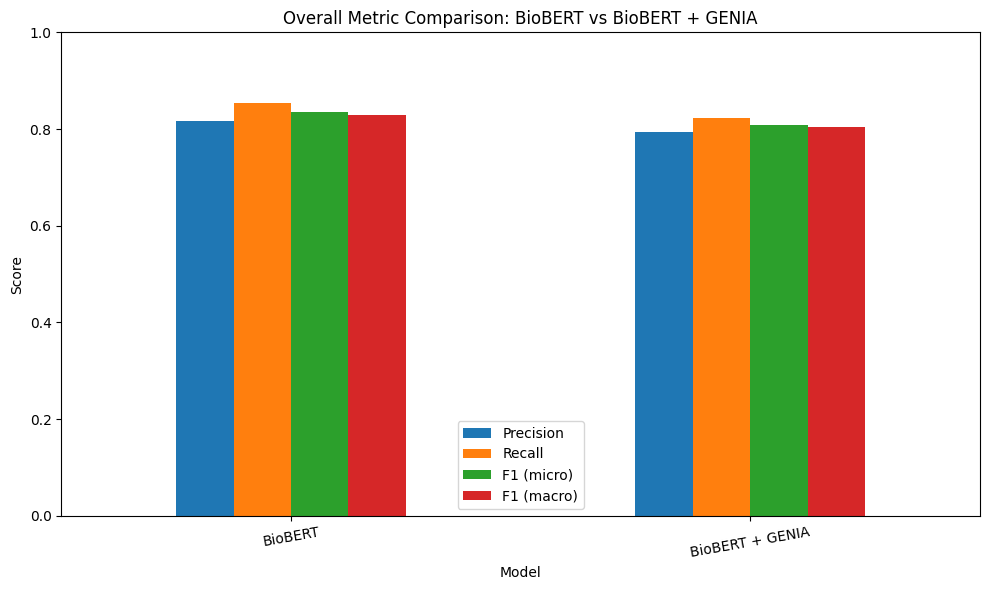

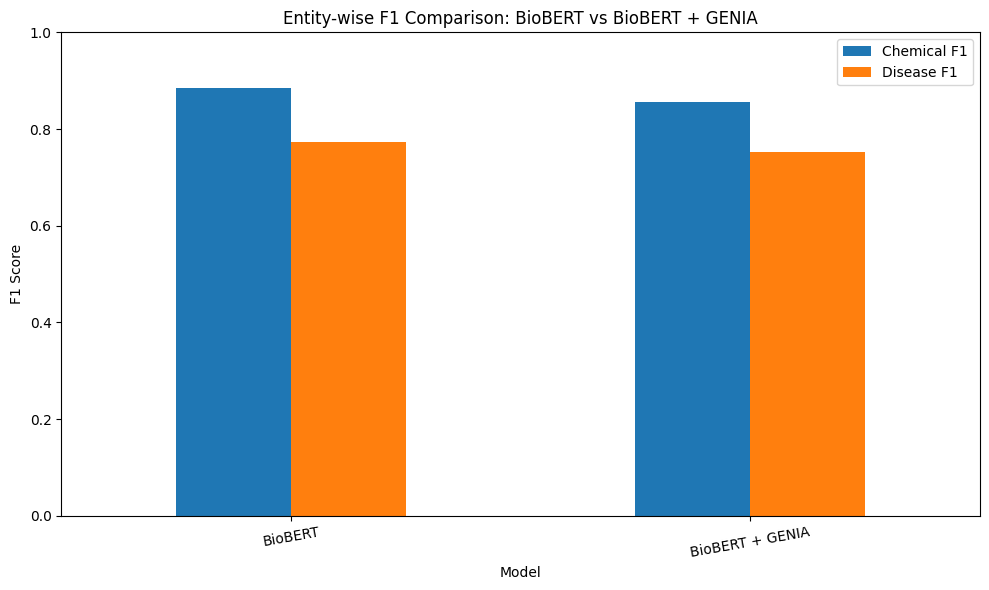

In [ ]:
plot_df = results_df.set_index("Model")[["Precision", "Recall", "F1 (micro)", "F1 (macro)"]]
ax = plot_df.plot(kind="bar", figsize=(10, 6))
ax.set_title("Overall Metric Comparison: BioBERT vs BioBERT + GENIA")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

entity_df = results_df.set_index("Model")[["Chemical F1", "Disease F1"]]
ax = entity_df.plot(kind="bar", figsize=(10, 6))
ax.set_title("Entity-wise F1 Comparison: BioBERT vs BioBERT + GENIA")
ax.set_ylabel("F1 Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()


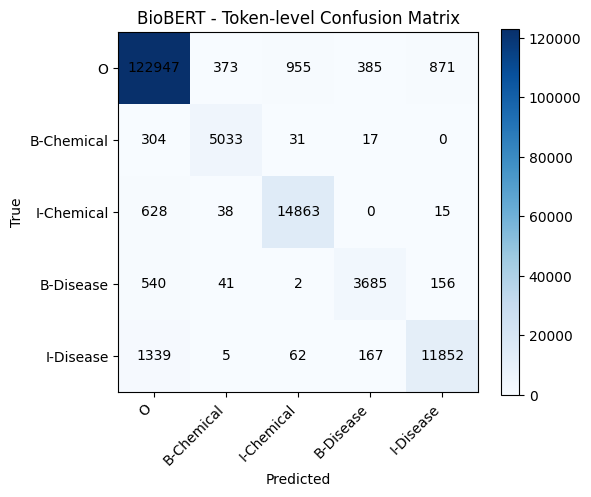

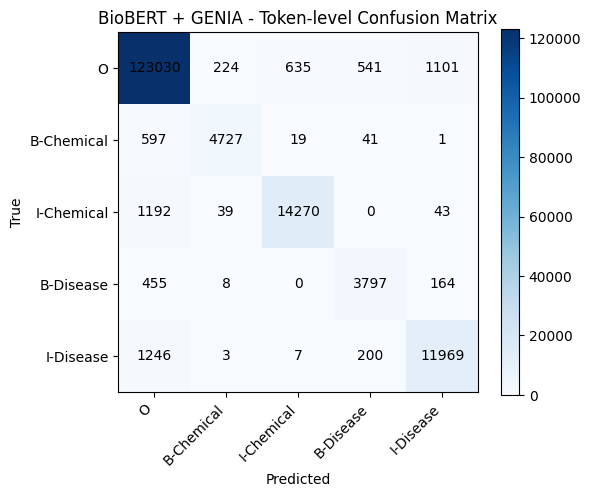

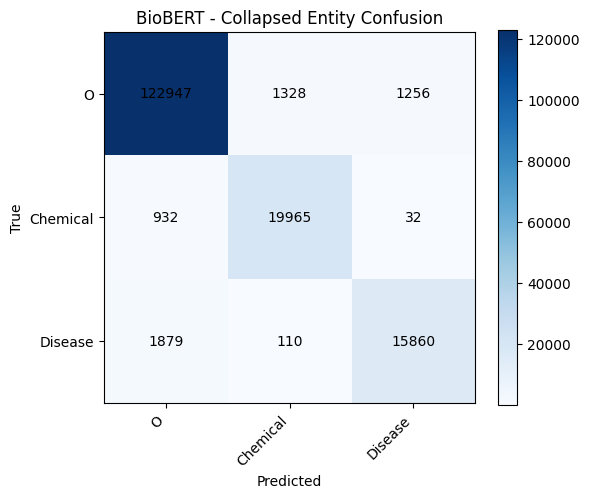

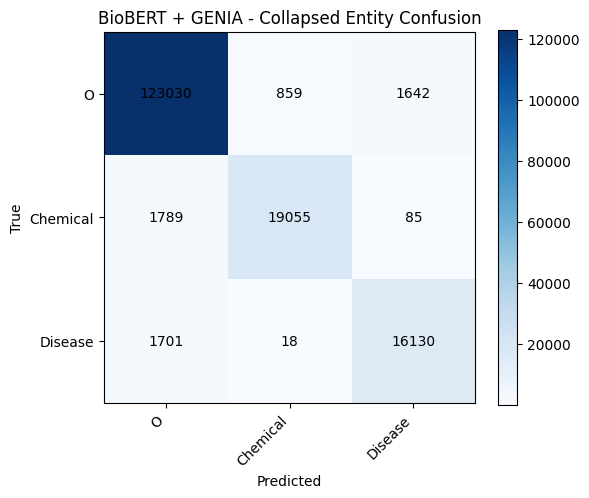

In [ ]:
labels_full = ["O", "B-Chemical", "I-Chemical", "B-Disease", "I-Disease"]

plot_confusion_matrix_simple(bio_true, bio_pred, labels_full, "BioBERT - Token-level Confusion Matrix")
plot_confusion_matrix_simple(biog_true, biog_pred, labels_full, "BioBERT + GENIA - Token-level Confusion Matrix")

bio_true_c = [collapse_entity(x) for x in bio_true]
bio_pred_c = [collapse_entity(x) for x in bio_pred]
biog_true_c = [collapse_entity(x) for x in biog_true]
biog_pred_c = [collapse_entity(x) for x in biog_pred]

labels_collapsed = ["O", "Chemical", "Disease"]

plot_confusion_matrix_simple(bio_true_c, bio_pred_c, labels_collapsed, "BioBERT - Collapsed Entity Confusion")
plot_confusion_matrix_simple(biog_true_c, biog_pred_c, labels_collapsed, "BioBERT + GENIA - Collapsed Entity Confusion")


## Step 9: Effect of GENIA Augmentation



,Base Model,Micro F1 Gain,Macro F1 Gain,Chemical F1 Gain,Disease F1 Gain
0,BioBERT,-0.0272,-0.0247,-0.0292,-0.0201


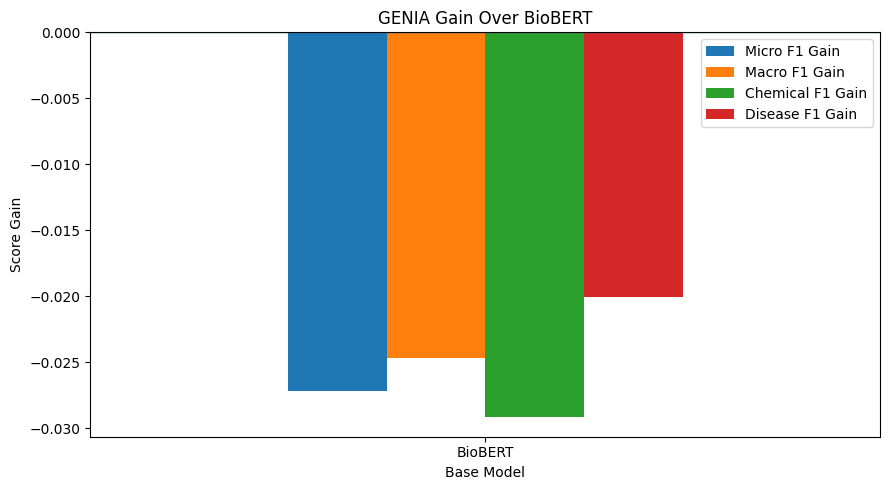

In [ ]:
improvement_df = pd.DataFrame({
    "Base Model": ["BioBERT"],
    "Micro F1 Gain": [
        biobert_genia_test_results["eval_f1_micro"] - biobert_test_results["eval_f1_micro"]
    ],
    "Macro F1 Gain": [
        biobert_genia_test_results["eval_f1_macro"] - biobert_test_results["eval_f1_macro"]
    ],
    "Chemical F1 Gain": [
        biobert_genia_test_results["eval_Chemical_f1"] - biobert_test_results["eval_Chemical_f1"]
    ],
    "Disease F1 Gain": [
        biobert_genia_test_results["eval_Disease_f1"] - biobert_test_results["eval_Disease_f1"]
    ]
}).round(4)

display(improvement_df)

ax = improvement_df.set_index("Base Model").plot(kind="bar", figsize=(9, 5))
ax.set_title("GENIA Gain Over BioBERT")
ax.set_ylabel("Score Gain")
plt.axhline(0, linewidth=1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Step 10: Error Analysis



In [ ]:
examples_shown = 0
print("=" * 100)
print("Examples where BioBERT failed but BioBERT + GENIA succeeded")
print("=" * 100)

for i in range(len(test_data)):
    tokens = test_data[i]["tokens"]
    actual_tags = test_data[i]["labels"]

    biobert_word_preds = reconstruct_tags(biobert_preds[i], biobert_dataset["test"][i]["labels"], label_names)
    biobert_genia_word_preds = reconstruct_tags(biobert_genia_preds[i], biobert_dataset["test"][i]["labels"], label_names)

    if len(biobert_word_preds) != len(tokens) or len(biobert_genia_word_preds) != len(tokens):
        continue

    biobert_correct = (biobert_word_preds == actual_tags)
    biobert_genia_correct = (biobert_genia_word_preds == actual_tags)

    if (not biobert_correct) and biobert_genia_correct:
        print(f"\nExample {examples_shown + 1}")
        print(f"{'Token':<20} | {'True':<15} | {'BioBERT':<15} | {'BioBERT+GENIA':<15}")
        print("-" * 86)
        for tk, tr, bp, bgp in zip(tokens, actual_tags, biobert_word_preds, biobert_genia_word_preds):
            mark = "*" if bp != tr else ""
            print(f"{tk:<20} | {tr:<15} | {bp + mark:<15} | {bgp:<15}")

        examples_shown += 1
        if examples_shown >= 10:
            break

if examples_shown == 0:
    print("No examples found.")


Examples where BioBERT failed but BioBERT + GENIA succeeded

Example 1
Token                | True            | BioBERT         | BioBERT+GENIA  
--------------------------------------------------------------------------------------
In                   | O               | O               | O              
order                | O               | O               | O              
to                   | O               | O               | O              
conduct              | O               | O               | O              
reliable             | O               | O               | O              
testing              | O               | O               | O              
in                   | O               | O               | O              
this                 | O               | O               | O              
regard               | O               | O               | O              
,                    | O               | O               | O              
it               